# MWE 04 — Manufactured PoreSpy extraction workflow (real extraction when PoreSpy is installed)

This notebook uses a deterministic synthetic 3D void image (`examples/data/manufactured_void_image.npy`) and
runs a **real** PoreSpy extraction (e.g. `snow2`) when the `test` environment is available.

Notebook fixes applied:
- Pixi-provided data path with a package-relative fallback when the kernel was started without refreshed env vars
- voxel-based PoreSpy geometry converted to physical units before import into `voids`
- headless PyVista screenshot path that avoids blocking notebook execution

It then imports the extracted network into `voids`, computes porosity and single-phase permeability, and saves
an HDF5 network file for reuse.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from voids.core.sample import SampleGeometry
from voids.core.provenance import Provenance
from voids.io import (
    ensure_cartesian_boundary_labels,
    from_porespy,
    scale_porespy_geometry,
)
from voids.io.hdf5 import save_hdf5
from voids.paths import data_path
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly

examples_data = data_path()

In [2]:
img_path = examples_data / "manufactured_void_image.npy"
im = np.load(img_path)
print(im.shape, im.dtype, float(im.mean()), "void fraction")
voxel_size = 1.0e-6  # 1 micron (example)
im.dtype

(48, 48, 48) bool 0.0642361111111111 void fraction


dtype('bool')

## Visualize the original void structure

View slices through the manufactured 3D void image to understand the pore space structure.

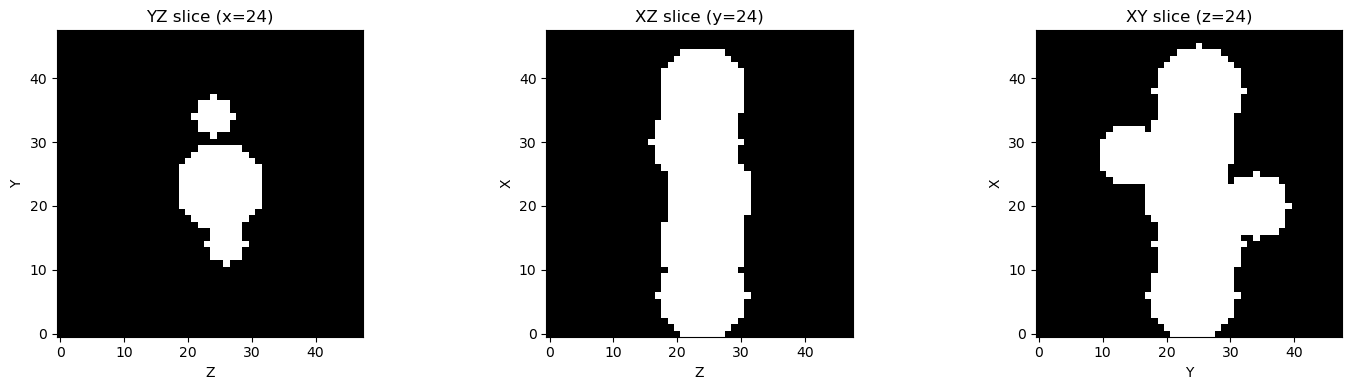

Void structure: (48, 48, 48), void fraction: 0.064


In [3]:
# Visualize the manufactured void image with slices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show slices through the middle of each dimension
mid_x, mid_y, mid_z = im.shape[0] // 2, im.shape[1] // 2, im.shape[2] // 2

axes[0].imshow(im[mid_x, :, :], cmap="gray", origin="lower")
axes[0].set_title(f"YZ slice (x={mid_x})")
axes[0].set_xlabel("Z")
axes[0].set_ylabel("Y")

axes[1].imshow(im[:, mid_y, :], cmap="gray", origin="lower")
axes[1].set_title(f"XZ slice (y={mid_y})")
axes[1].set_xlabel("Z")
axes[1].set_ylabel("X")

axes[2].imshow(im[:, :, mid_z], cmap="gray", origin="lower")
axes[2].set_title(f"XY slice (z={mid_z})")
axes[2].set_xlabel("Y")
axes[2].set_ylabel("X")

plt.tight_layout()
plt.show()
print(f"Void structure: {im.shape}, void fraction: {im.mean():.3f}")

In [4]:
# Real PoreSpy extraction (optional dependency)
try:
    import porespy as ps

    print("Backend version:", ps.__version__)

    # Preferred path: snow2 returns an object with .network in modern PoreSpy examples/docs.
    snow = ps.networks.snow2(phases=im)
    if hasattr(snow, "network"):
        net_dict = snow.network
    elif isinstance(snow, dict) and "network" in snow:
        net_dict = snow["network"]
    elif isinstance(snow, dict) and "throat.conns" in snow and "pore.coords" in snow:
        net_dict = snow
    else:
        # Fallback path for API differences: attempt regions_to_network on labels/regions
        regions = getattr(snow, "regions", None)
        if regions is None and isinstance(snow, dict):
            regions = snow.get("regions", None)
        if regions is None:
            raise RuntimeError(
                "Could not find a network dict or regions in snow2 result"
            )
        net_dict = ps.networks.regions_to_network(regions)

    print("Extracted keys sample:", list(net_dict.keys())[:10])
except ImportError as exc:
    raise RuntimeError(
        "PoreSpy is not installed. Run this notebook in the `test` pixi environment."
    ) from exc

Backend version: 3.0.4


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Extracted keys sample: ['throat.conns', 'pore.coords', 'pore.all', 'throat.all', 'pore.region_label', 'pore.phase', 'throat.phases', 'pore.region_volume', 'pore.equivalent_diameter', 'pore.local_peak']


In [5]:
# Add simple boundary labels if extraction output does not provide them
# Convert common PoreSpy voxel-based geometry to physical SI units before import.
net_dict = scale_porespy_geometry(net_dict, voxel_size=voxel_size)
net_dict = ensure_cartesian_boundary_labels(net_dict, axes=("x",))

sx, sy, sz = im.shape
sample = SampleGeometry(
    voxel_size=voxel_size,
    bulk_shape_voxels=tuple(im.shape),
    lengths={"x": sx * voxel_size},
    cross_sections={"x": sy * sz * voxel_size**2},
    units={"length": "m", "pressure": "Pa"},
)
prov = Provenance(
    source_kind="porespy",
    source_version=getattr(ps, "__version__", None),
    extraction_method="snow2",
)
net = from_porespy(net_dict, sample=sample, provenance=prov, strict=True)
net

Network(throat_conns=array([[0, 1],
       [0, 8],
       [1, 2],
       [1, 3],
       [2, 3],
       [3, 4],
       [3, 5],
       [4, 5],
       [5, 7],
       [6, 7]]), pore_coords=array([[8.36804452e-06, 2.69038156e-05, 2.70000000e-05],
       [1.70342960e-05, 2.80460289e-05, 2.68980144e-05],
       [2.30237624e-05, 3.70792079e-05, 2.69960396e-05],
       [2.50071878e-05, 2.59442947e-05, 2.80548068e-05],
       [3.10099206e-05, 1.69186508e-05, 2.90019841e-05],
       [3.28908582e-05, 2.71054104e-05, 2.59701493e-05],
       [3.69681275e-05, 3.30438247e-05, 3.50557769e-05],
       [4.15158546e-05, 2.80378964e-05, 2.70433101e-05],
       [1.00000000e-06, 2.70000000e-05, 2.70000000e-05]]), sample=SampleGeometry(voxel_size=1e-06, bulk_shape_voxels=(48, 48, 48), bulk_volume=None, lengths={'x': 4.8e-05}, cross_sections={'x': 2.304e-09}, axis_map={}, units={'length': 'm', 'pressure': 'Pa'}), provenance=Provenance(source_kind='porespy', source_version='3.0.4', extraction_method='snow2', se

In [6]:
print("phi_abs(network volumes / bulk) =", absolute_porosity(net))
print("phi_eff_x =", effective_porosity(net, axis="x"))

phi_abs(network volumes / bulk) = 0.06480577256944446
phi_eff_x = 0.06480577256944446


In [7]:
# Single-phase solve: use robust fallback conductance model unless enough geometry is present.
bc = PressureBC("inlet_xmin", "outlet_xmax", pin=2.0e5, pout=1.0e5)
res = solve(
    net,
    fluid=FluidSinglePhase(viscosity=1.0e-3),
    bc=bc,
    axis="x",
    options=SinglePhaseOptions(conductance_model="valvatne_blunt", solver="direct"),
)
print("Q =", res.total_flow_rate)
print("Kx =", res.permeability["x"])
print("mbe =", res.mass_balance_error)

Q = 1.9744449482110044e-10
Kx = 4.113426975439593e-14
mbe = 8.383665599458318e-25


In [8]:
# Save extracted network for reuse
out_h5 = examples_data / "manufactured_porespy_network_voids.h5"
save_hdf5(net, out_h5)
out_npz = examples_data / "manufactured_porespy_network_raw.npz"
np.savez_compressed(
    out_npz, **{k: np.asarray(v) for k, v in net_dict.items() if hasattr(v, "shape")}
)
print("Saved:", out_h5)
print("Saved:", out_npz)

Saved: /Users/dtvolpatto/Work/voids/examples/data/manufactured_porespy_network_voids.h5
Saved: /Users/dtvolpatto/Work/voids/examples/data/manufactured_porespy_network_raw.npz


## Interactive network visualization

Visualize the extracted pore network with pores colored by pressure using Plotly for full 3D interactivity.

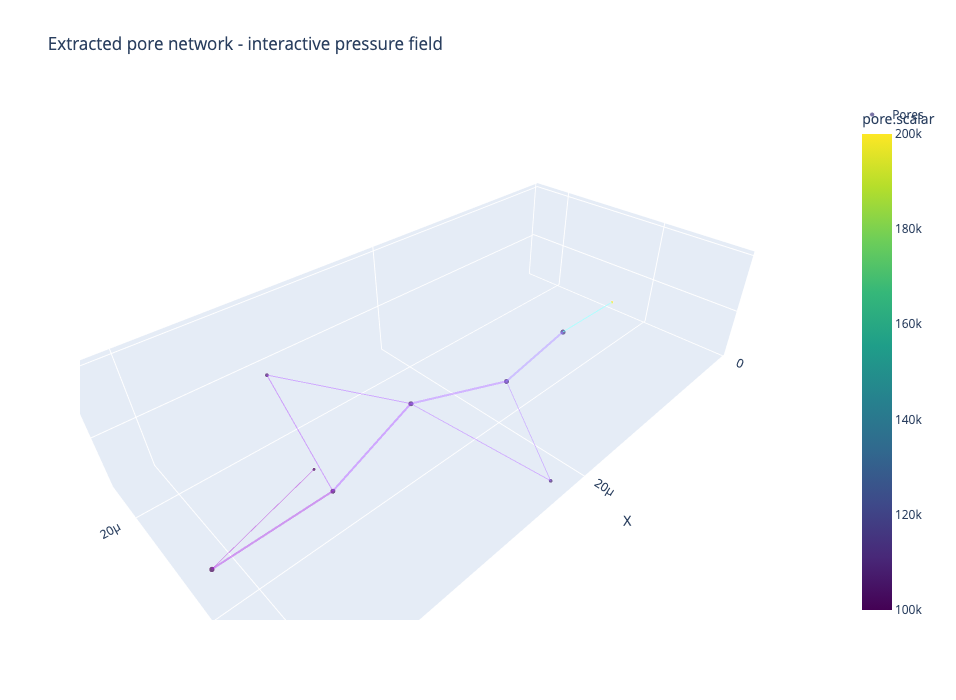

Network: 9 pores, 10 throats
Pressure range: 1.00e+05 to 2.00e+05 Pa


In [9]:
try:
    fig = plot_network_plotly(
        net,
        point_scalars=res.pore_pressure,
        max_throats=1000,
        title="Extracted pore network - interactive pressure field",
        layout_kwargs={"width": 900, "height": 700},
    )
    fig.show()
    print(f"Network: {net.Np} pores, {net.Nt} throats")
    print(
        f"Pressure range: {res.pore_pressure.min():.2e} to {res.pore_pressure.max():.2e} Pa"
    )
except ImportError as exc:
    print(exc)